# Preparación del entorno

Monto mi Google Drive, donde tengo los conjuntos de datos, instalo fast.ai, e importo varias librerías para utilizar despues.

In [0]:


from google.colab import drive
drive.mount('/content/gdrive')


Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/gdrive


In [0]:
# Imports necesarios para operar
!pip install fastai==0.7.0
from termcolor import colored

import math
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import EarlyStopping,ReduceLROnPlateau

from sklearn import preprocessing
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
from sklearn.model_selection import train_test_split

from fastai.structured import train_cats, proc_df, draw_tree

plt.rcParams["figure.figsize"] = (30,20)

     |████████████████████████████████| 122kB 2.8MB/s 
     |████████████████████████████████| 496.4MB 27kB/s 
     |████████████████████████████████| 1.5MB 37.3MB/s 
  Stored in directory: /root/.cache/pip/wheels/9f/78/26/fb8c0acb91a100dc8914bf236c4eaa4b207cb876893c40b745
Successfully built bcolz
ERROR: torchvision 0.3.0 has requirement torch>=1.1.0, but you'll have torch 0.3.1 which is incompatible.
  Found existing installation: torch 1.1.0
    Uninstalling torch-1.1.0:
      Successfully uninstalled torch-1.1.0
  Found existing installation: fastai 1.0.55
    Uninstalling fastai-1.0.55:
      Successfully uninstalled fastai-1.0.55


Using TensorFlow backend.


In [0]:
#Esta función permite graficar las matrices de confusión de manera agradable a la vista 

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Purples):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots(figsize=(20, 10))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='Copista verdadero',
           xlabel='Copista predicho')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax


np.set_printoptions(precision=3)

# Pre-procesamiento del dataset

Una vez preparado el entorno de ejecución, es momento de leer los archivos de datos: 

avila-tr es el conjunto de entrenamiento, y 

avila-ts es el conjunto de test.

Posteriormente, realizo algunas transformaciones sobre las matrices, sobre las que voy a trabajar después.

In [0]:
#Leo los archivos
AvilaTr = pd.read_csv('gdrive/My Drive/MATLAB/Avila/avila-tr.txt', low_memory=False, header=None)
AvilaTs = pd.read_csv('gdrive/My Drive/MATLAB/Avila/avila-ts.txt', low_memory=False, header=None)


#Chequeo que estén bien cargadas las matrices
print(AvilaTr.head(3))
print(AvilaTs.head(3))

         0         1         2         3   ...        7         8         9   10
0  0.266074 -0.165620  0.320980  0.483299  ...  0.929823  0.251173  0.159345   A
1  0.130292  0.870736 -3.210528  0.062493  ...  0.636203  0.282354  0.515587   A
2 -0.116585  0.069915  0.068476 -0.783147  ... -0.888236 -0.123005  0.582939   A

[3 rows x 11 columns]
         0         1         2         3   ...        7         8         9   10
0 -3.498799  0.250492  0.232070  1.224178  ... -0.165983 -0.123005  1.087144   W
1  0.204355 -0.354049  0.320980  0.410166  ...  0.181844  2.090879 -2.009758   A
2  0.759828 -1.304042 -0.023991 -0.973663  ... -0.450127  0.469443  0.060952   I

[3 rows x 11 columns]


In [0]:
# Procesamiento del dataframe:

#Convierto en categorías los datos no-numéricos
train_cats(AvilaTr)
train_cats(AvilaTs)

#Agrego nombres de columnas para poder llamarlas
AvilaTr.columns= "V0","V1","V2","V3","V4","V5","V6","V7","V8","V9","Copis"
AvilaTs.columns= "V0","V1","V2","V3","V4","V5","V6","V7","V8","V9","Copis"

print(AvilaTr.head(3))
print(AvilaTs.head(3))

# Siendo "Copis" la variable dependiente, se la indica como tal.
# Mediante `proc_df` la extraigo del dataframe.
ATr, ATrT, nas = proc_df(AvilaTr, "Copis")
ATs, ATsT, nas = proc_df(AvilaTs, "Copis")
Copistas = np.arange(12)

print(ATr.head(3))
print(ATs.head(3))

         V0        V1        V2        V3  ...        V7        V8        V9  Copis
0  0.266074 -0.165620  0.320980  0.483299  ...  0.929823  0.251173  0.159345      A
1  0.130292  0.870736 -3.210528  0.062493  ...  0.636203  0.282354  0.515587      A
2 -0.116585  0.069915  0.068476 -0.783147  ... -0.888236 -0.123005  0.582939      A

[3 rows x 11 columns]
         V0        V1        V2        V3  ...        V7        V8        V9  Copis
0 -3.498799  0.250492  0.232070  1.224178  ... -0.165983 -0.123005  1.087144      W
1  0.204355 -0.354049  0.320980  0.410166  ...  0.181844  2.090879 -2.009758      A
2  0.759828 -1.304042 -0.023991 -0.973663  ... -0.450127  0.469443  0.060952      I

[3 rows x 11 columns]
         V0        V1        V2  ...        V7        V8        V9
0  0.266074 -0.165620  0.320980  ...  0.929823  0.251173  0.159345
1  0.130292  0.870736 -3.210528  ...  0.636203  0.282354  0.515587
2 -0.116585  0.069915  0.068476  ... -0.888236 -0.123005  0.582939

[3 rows x 10 

# Conjunto de datos de validación

Para eso, vamos a separar el dataset inicial en sets de entrenamiento y de validacion, para dirimir en qué época deberíamos detener el training para no overfittear.

Segunda versión: Antes la separación de los conjuntos era siempre igual, ahora se randomiza antes de mezclar.

El tamaño del set es resultado de probar desde .20 a .06.


In [0]:

#X_train, X_valid, y_train, y_valid = train_test_split(ATrM, ATrT, test_size=0.1)
X_train, X_valid, y_train, y_valid = train_test_split(ATr, ATrT, test_size=0.15)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape



((8865, 10), (8865,), (1565, 10), (1565,))

# Creación de la Red Neuronal

Creamos una red FF-FC, 3 capas ocultas ReLu, de 80, 80 y 40 neuronas, y una capa de salida *softmax* de 12 neuronas.

Entre cada capa y la siguiente hay un dropout de 0.1


In [0]:
model = keras.Sequential([
    keras.layers.Dense(80, activation=tf.nn.tanh),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(80, activation=tf.nn.tanh),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(40, activation=tf.nn.tanh),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(12, activation=tf.nn.softmax)
])

Ya está creada nuestra red. Vamos a compilar el modelo y definir algunos hiperparámetros antes de comenzar el entrenamiento:

Optimización:  Adam, ADAptative Moment estimation. Es una combinación de Stochastic gradient descent con momento y RMSprop. Básicamente, asigna una tasa de aprendizaje a cada parámetro, y la actualiza de alguna manera. Es el primero que probé. Los otros no han dado tan buenos resultados.

Loss: Como se trata de un problema de clasificación, vamos a usar la entropía cruzada categórica como función de costo. La diferencia entre la sparse y la regular es que estamos comparando una variable sola, donde se guarda el índice de copista, en lugar de una variable binaria para cada copista posible.

Métrica: Es la función utilizada para juzgar el desempeño del modelo. En este caso compara el índice de la neurona de salida con mayor activación para un patrón determinado con el índice de copista que produjo efectivamente ese fragmento.

A continuación, creo dos llamados para utilizar dentro del entrenamiento:

  History: Permite grabar al finalizar cada época los pesos de la red, además de los valores observados de Loss y Accuracy, 
  
  EarlyStopping: Permite evaluar la Accuracy sobre el conjunto de validación. Va comparando la Accuracy con la de Época -1, y cuando el delta es menor a 0 detiene el entrenamiento. Tiene un parámetro de paciencia, que permite continuar 100 épocas más, por si el descenso de accuracy era solamente momentáneo. Tras detener el entrenamiento, retorna los valores de los pesos a los obtenidos en la mejor iteración.

In [0]:
modelito = keras.optimizers.Adam(lr=0.002)
modelito2 = keras.optimizers.RMSprop(lr=0.003)

model.compile(optimizer=modelito2,
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1)
reduceLR=keras.callbacks.ReduceLROnPlateau(monitor='sparse_categorical_accuracy', factor=0.995, patience=10, verbose=1, mode='auto', min_delta=0.0001, cooldown=0, min_lr=0) 
historia= keras.callbacks.History()
puntodecorte = keras.callbacks.EarlyStopping(monitor='val_sparse_categorical_accuracy', min_delta=0, patience=1000, 
                                             verbose=1, mode='auto', baseline=None, restore_best_weights=True)
puntodecorte2 = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=1000, 
                                             verbose=1, mode='auto', baseline=None, restore_best_weights=True)
#corte monitorear ACC
esc =[historia, puntodecorte2, reduceLR]


Entrenamos la red por mil épocas, o hasta que no mejore más el loss de validación por puntodecorte épocas. 

In [0]:
history = model.fit(X_train.values, y_train, validation_data=(X_valid, y_valid), epochs=20000, verbose=0, callbacks=esc)


Epoch 00140: ReduceLROnPlateau reducing learning rate to 0.002985000025946647.

Epoch 00167: ReduceLROnPlateau reducing learning rate to 0.0029700749123003334.

Epoch 00186: ReduceLROnPlateau reducing learning rate to 0.0029552246269304305.

Epoch 00196: ReduceLROnPlateau reducing learning rate to 0.002940448474837467.

Epoch 00212: ReduceLROnPlateau reducing learning rate to 0.0029257462243549525.

Epoch 00235: ReduceLROnPlateau reducing learning rate to 0.002911117412149906.

Epoch 00245: ReduceLROnPlateau reducing learning rate to 0.0028965618065558375.

Epoch 00255: ReduceLROnPlateau reducing learning rate to 0.0028820789442397655.

Epoch 00265: ReduceLROnPlateau reducing learning rate to 0.0028676685935351996.

Epoch 00275: ReduceLROnPlateau reducing learning rate to 0.0028533302911091596.

Epoch 00288: ReduceLROnPlateau reducing learning rate to 0.002839063573628664.

Epoch 00298: ReduceLROnPlateau reducing learning rate to 0.0028248682094272224.

Epoch 00323: ReduceLROnPlateau 

In [0]:
print(colored('Datos de entrenamiento:', 'red'))
train_loss, train_acc = model.evaluate(X_train, y_train)
print(colored('Datos de validación:', 'blue'))
valid_loss, valid_acc = model.evaluate(X_valid, y_valid)
print(colored('Datos de test:', 'green'))
#res_loss, res_acc = model.evaluate(ATsM, ATsT)
res_loss, res_acc = model.evaluate(ATs, ATsT)

Datos de entrenamiento:
8865/8865 [==============================] - 0s 29us/sample - loss: 0.0014 - sparse_categorical_accuracy: 0.9998
Datos de validación:
1565/1565 [==============================] - 0s 28us/sample - loss: 0.0221 - sparse_categorical_accuracy: 0.9936
Datos de test:
10437/10437 [==============================] - 0s 26us/sample - loss: 0.0178 - sparse_categorical_accuracy: 0.9954


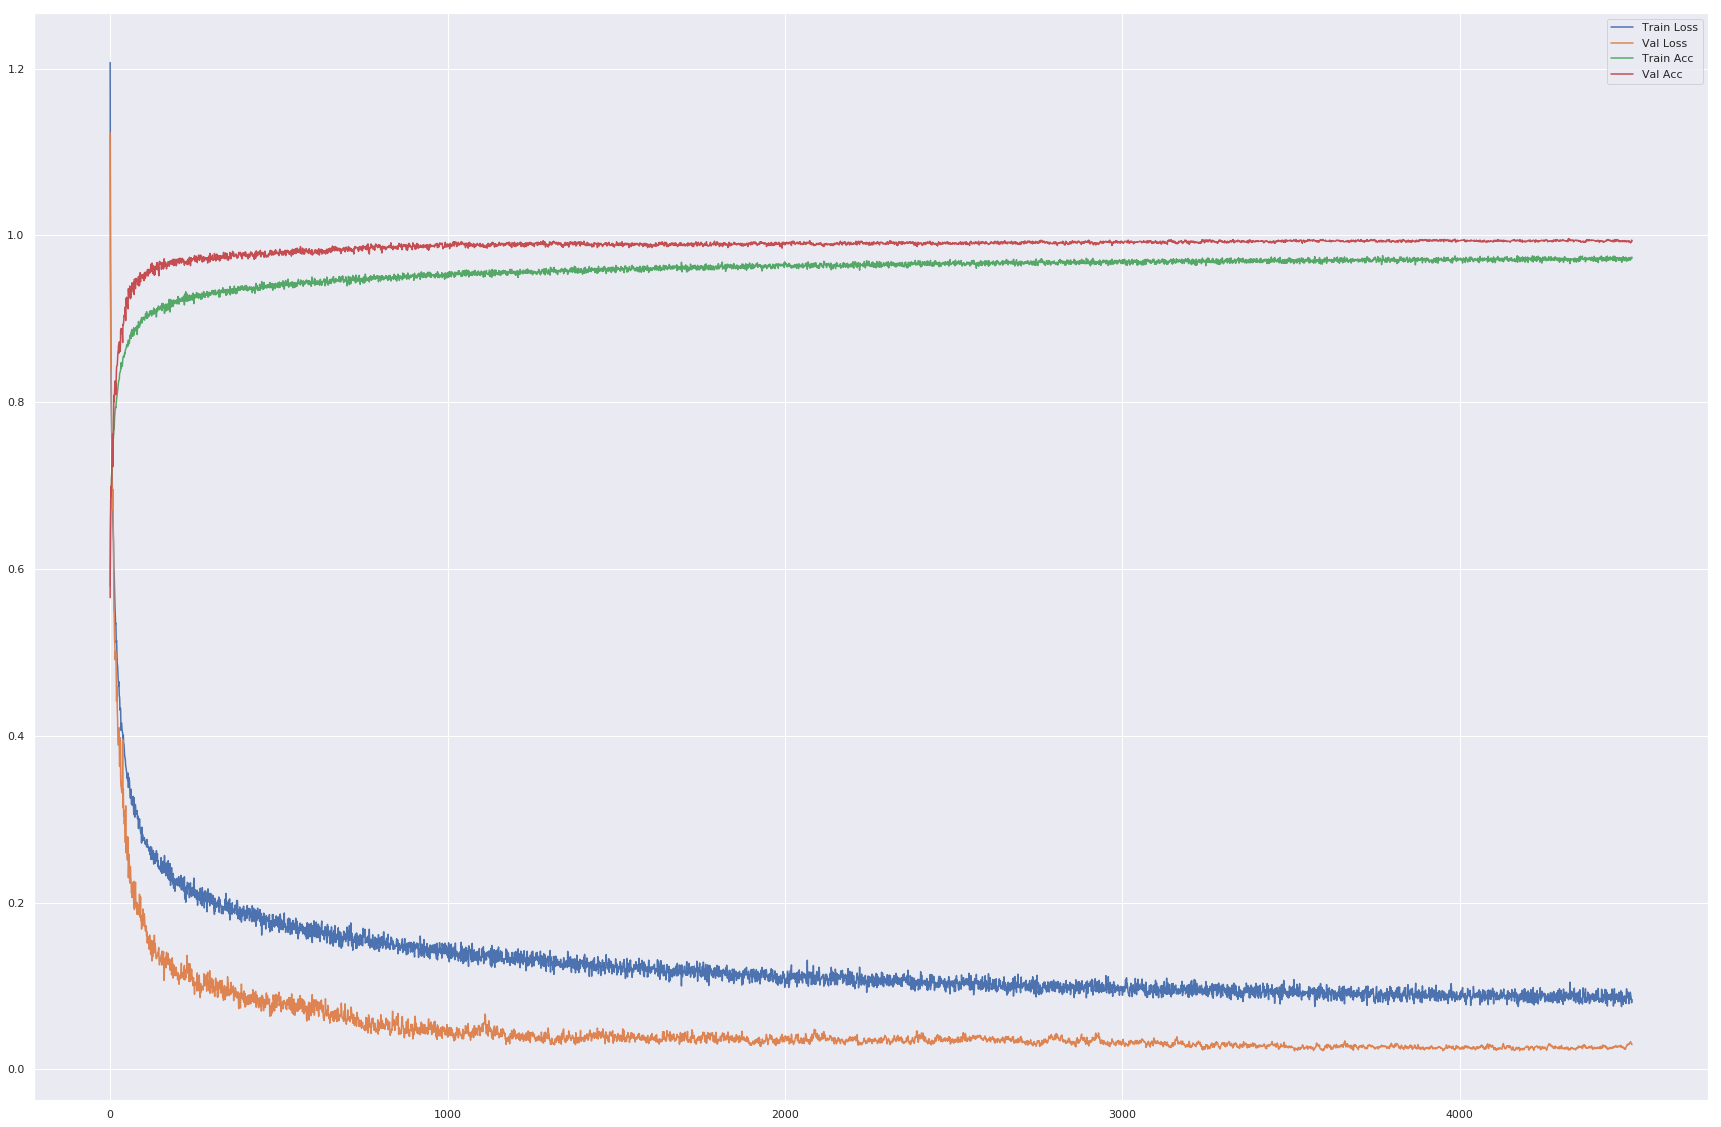

In [0]:
#Progresión de Loss y Accuracy según épocas

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label="Val Loss")
plt.plot(history.history['sparse_categorical_accuracy'], label="Train Acc")
plt.plot(history.history['val_sparse_categorical_accuracy'], label="Val Acc")
plt.legend()
plt.show()

En este bloque primero creo la matriz de salida (Número de casos de test por 12 salidas) para el conjunto de datos de test de la RN. Luego creo un vector del mismo tamaño, donde guardo posteriormente el número de copista que tenga mejor puntaje según la red, ya que necesito solamente una respuesta por patrón.

Confusion matrix, without normalization
[[4274    0    0    0    3    5    2    5    2    1    0    0]
 [   0    5    0    0    0    0    0    0    0    0    0    0]
 [   0    0  100    0    0    0    0    3    0    0    0    0]
 [   1    0    0  352    1    0    0    0    0    0    0    0]
 [   0    0    1    0 1090    0    0    0    0    0    3    0]
 [   8    0    2    0    1 1956    0    1    0    0    0    0]
 [   1    0    0    0    0    0  445    0    0    0    0    0]
 [   1    0    0    0    0    1    0  510    0    0    1    0]
 [   1    0    0    0    0    0    0    0  830    0    0    0]
 [   0    0    0    0    0    0    0    0    0   44    0    0]
 [   0    0    0    1    0    0    0    1    0    0  516    1]
 [   0    0    0    0    0    0    0    0    0    0    2  266]]
Normalized confusion matrix
[[0.996 0.    0.    0.    0.001 0.001 0.    0.001 0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.971 0.   

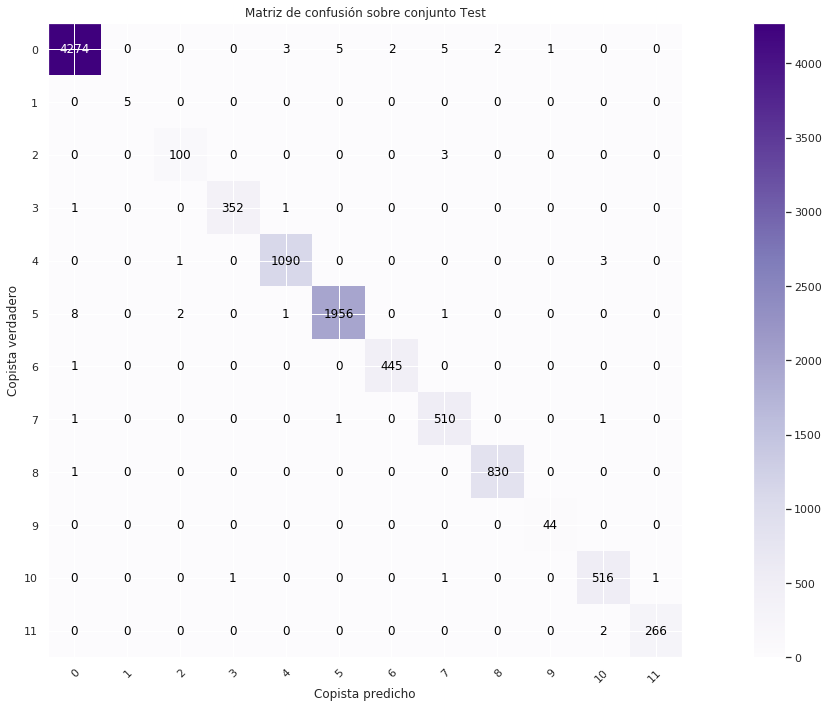

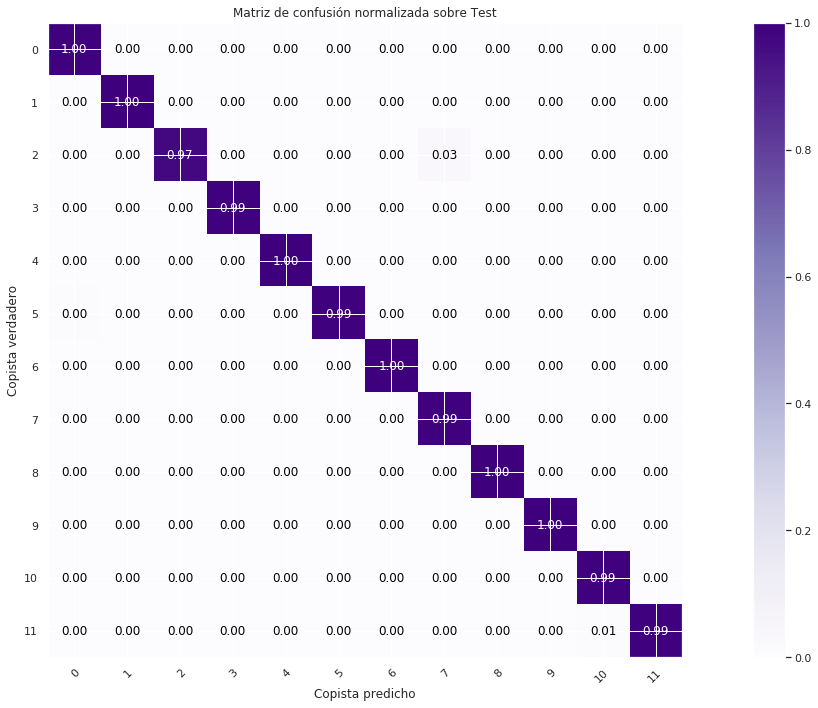

In [0]:

 
predictions = model.predict(ATs)
prediccion =np.zeros(len(ATs), dtype=int)
for x in range(1, len(ATs)):
   prediccion[x] = np.argmax(predictions[x])

# Graficar la matriz de confusión con número de casos por condición
plot_confusion_matrix(prediccion, ATsT, classes=Copistas,
                      title='Matriz de confusión sobre conjunto Test')

# Graficar la matriz de confusión normalizada
plot_confusion_matrix(prediccion, ATsT, classes=Copistas, normalize=True,
                      title='Matriz de confusión normalizada sobre Test')

plt.show()

Puntaje récord:

Datos de entrenamiento:
 loss: 0.0014 - sparse_categorical_accuracy: 0.9998
Datos de validación:
 loss: 0.0221 - sparse_categorical_accuracy: 0.9936
Datos de test:
 loss: 0.0178 - sparse_categorical_accuracy: 0.9954
 
 Si se equivoca menos de 1 cada 200 copistas... ya me quedo contento :)